In [181]:
import numpy as np
import scipy.io
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import pandas as pd

# Settings

In [182]:
SEQ_LENGTH = 64
HIDDEN_SIZE = 64
NUM_LAYERS = 2
DROPOUT = 0.2
LEARNING_RATE = 0.001
BATCH_SIZE = 32
EPOCHS = 120

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load data

In [183]:
train_mat = scipy.io.loadmat("Xtrain.mat")
test_mat = scipy.io.loadmat("Xtest.mat")

print(train_mat.keys())
print(test_mat.keys())

train_data = train_mat["Xtrain"].flatten()
test_data = test_mat["Xtest"].flatten()

dict_keys(['__header__', '__version__', '__globals__', 'Xtrain'])
dict_keys(['__header__', '__version__', '__globals__', 'Xtest'])


# Scale fit only on train data

In [184]:
scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(
    train_data.reshape(-1, 1)
)

test_scaled = scaler.transform(
    test_data.reshape(-1, 1)
)

In [185]:
split_idx = int(len(train_scaled) * 0.8)

train_part = train_scaled[:split_idx]
val_part = train_scaled[split_idx:]

def create_sequences(data, seq_length):

    X = []
    y = []

    for i in range(len(data) - seq_length):

        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])

    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_part, SEQ_LENGTH)
X_val, y_val = create_sequences(val_part, SEQ_LENGTH)

In [186]:
class TimeSeriesDataset(Dataset):

    def __init__(self, X, y):

        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = TimeSeriesDataset(X_train, y_train)
val_dataset = TimeSeriesDataset(X_val, y_val)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# LSTM model

In [187]:
class LSTMModel(nn.Module):

    def __init__(self,
                 input_size=1,
                 hidden_size=64,
                 num_layers=2,
                 dropout=0.2):

        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )

        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):

        out, _ = self.lstm(x)

        # Take last timestep
        out = out[:, -1, :]

        out = self.fc(out)

        return out

model = LSTMModel(
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT
).to(device)

# loss + optim

In [188]:
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

# Training with ES

In [189]:
train_losses = []
val_losses = []

best_val_loss = float("inf")
patience = 15
counter = 0
best_model_state = None

for epoch in range(EPOCHS):
    model.train()

    running_train_loss = 0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        outputs = model(X_batch)

        loss = criterion(outputs, y_batch)

        loss.backward()

        optimizer.step()

        running_train_loss += loss.item()

    avg_train_loss = running_train_loss / len(train_loader)
    

    model.eval()

    running_val_loss = 0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)

            loss = criterion(outputs, y_batch)

            running_val_loss += loss.item()

    avg_val_loss = running_val_loss / len(val_loader)

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        counter = 0
        best_model_state = model.state_dict()
    else:
        counter += 1

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Train Loss: {avg_train_loss:.6f} | "
        f"Val Loss: {avg_val_loss:.6f}"
    )

    if counter >= patience:
        print(f"Early stopping at epoch {epoch+1} with best val loss {best_val_loss:.6f}")
        TRAINED_EPOCHS = epoch + 1
        break

if best_model_state is not None:
    model.load_state_dict(best_model_state)

Epoch [1/120] | Train Loss: 0.047373 | Val Loss: 0.039861
Epoch [2/120] | Train Loss: 0.035910 | Val Loss: 0.038102
Epoch [3/120] | Train Loss: 0.034978 | Val Loss: 0.037948
Epoch [4/120] | Train Loss: 0.034697 | Val Loss: 0.037567
Epoch [5/120] | Train Loss: 0.034129 | Val Loss: 0.036669
Epoch [6/120] | Train Loss: 0.032637 | Val Loss: 0.033219
Epoch [7/120] | Train Loss: 0.027110 | Val Loss: 0.013804
Epoch [8/120] | Train Loss: 0.014763 | Val Loss: 0.016247
Epoch [9/120] | Train Loss: 0.014456 | Val Loss: 0.008404
Epoch [10/120] | Train Loss: 0.012187 | Val Loss: 0.011686
Epoch [11/120] | Train Loss: 0.011915 | Val Loss: 0.009329
Epoch [12/120] | Train Loss: 0.011007 | Val Loss: 0.009254
Epoch [13/120] | Train Loss: 0.010303 | Val Loss: 0.007463
Epoch [14/120] | Train Loss: 0.009892 | Val Loss: 0.007300
Epoch [15/120] | Train Loss: 0.009069 | Val Loss: 0.006393
Epoch [16/120] | Train Loss: 0.008046 | Val Loss: 0.006883
Epoch [17/120] | Train Loss: 0.007433 | Val Loss: 0.006018
Epoch 

# Plot training

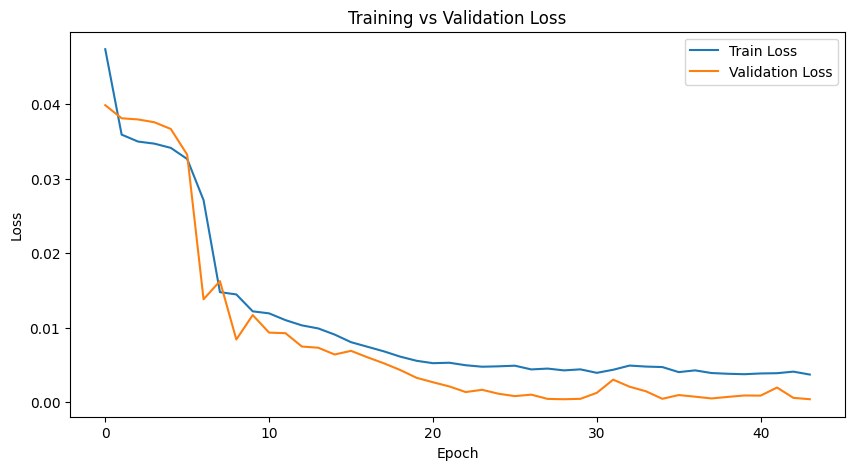

In [190]:
plt.figure(figsize=(10, 5))

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.show()

# Hyperparam

In [191]:
# import itertools

# seq_lengths = [10, 20, 50, 100]
# hidden_sizes = [32, 64]
# learning_rates = [0.001, 0.0005]

# results = []

# # GRID SEARCH
# for seq_length, hidden_size, lr in itertools.product(
#     seq_lengths,
#     hidden_sizes,
#     learning_rates,
# ):

#     print("\n====================================")
#     print(f"SEQ_LENGTH: {seq_length}")
#     print(f"HIDDEN_SIZE: {hidden_size}")
#     print(f"LEARNING_RATE: {lr}")
#     print("====================================")


#     # CREATE SEQUENCES
#     X_train, y_train = create_sequences(
#         train_part,
#         seq_length
#     )

#     X_val, y_val = create_sequences(
#         val_part,
#         seq_length
#     )

#     train_dataset = TimeSeriesDataset(
#         X_train,
#         y_train
#     )

#     val_dataset = TimeSeriesDataset(
#         X_val,
#         y_val
#     )

#     train_loader = DataLoader(
#         train_dataset,
#         batch_size=32,
#         shuffle=False
#     )

#     val_loader = DataLoader(
#         val_dataset,
#         batch_size=32,
#         shuffle=False
#     )

#     # MODEL
#     model = LSTMModel(
#         hidden_size=hidden_size,
#         num_layers=NUM_LAYERS,
#         dropout=0.2
#     ).to(device)

#     criterion = nn.MSELoss()

#     optimizer = torch.optim.Adam(
#         model.parameters(),
#         lr=lr
#     )


#     # TRAIN
#     EPOCHS_HYPER = 40

#     for epoch in range(EPOCHS_HYPER):

#         model.train()

#         for X_batch, y_batch in train_loader:

#             X_batch = X_batch.to(device)
#             y_batch = y_batch.to(device)

#             optimizer.zero_grad()

#             outputs = model(X_batch)

#             loss = criterion(outputs, y_batch)

#             loss.backward()

#             optimizer.step()


#     # VALIDATION
#     model.eval()

#     predictions = []

#     with torch.no_grad():

#         for X_batch, _ in val_loader:

#             X_batch = X_batch.to(device)

#             outputs = model(X_batch)

#             predictions.extend(
#                 outputs.cpu().numpy()
#             )

#     predictions = np.array(predictions)

#     # inverse scale
#     predictions_inverse = scaler.inverse_transform(
#         predictions
#     )

#     y_val_inverse = scaler.inverse_transform(
#         y_val
#     )

#     # metrics
#     mae = mean_absolute_error(
#         y_val_inverse,
#         predictions_inverse
#     )

#     mse = mean_squared_error(
#         y_val_inverse,
#         predictions_inverse
#     )

#     print(f"Validation MAE: {mae:.6f}")
#     print(f"Validation MSE: {mse:.6f}")

#     # save result
#     results.append({
#         "seq_length": seq_length,
#         "learning_rate": lr,
#         "num_layers": NUM_LAYERS,
#         "mae": mae,
#         "mse": mse
#     })


# # BEST PARAMETERS
# best_result = min(
#     results,
#     key=lambda x: x["mae"]
# )

# print("\n====================================")
# print("BEST HYPERPARAMETERS")
# print(best_result)
# print("====================================")

{'seq_length': 20, 'learning_rate': 0.001, 'num_layers': 2, 'mae': 2.7298570844862198, 'mse': 15.266714326768568}

In [192]:
# SEQ_LENGTH = best_result["seq_length"]
# LEARNING_RATE = best_result["learning_rate"]

In [193]:
SEQ_LENGTH = 64
LEARNING_RATE = 0.001

# retraining on full train set

## After choosing hyperparam

In [194]:
X_full, y_full = create_sequences(train_scaled, SEQ_LENGTH)

full_dataset = TimeSeriesDataset(X_full, y_full)

full_loader = DataLoader(
    full_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

final_model = LSTMModel(
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT
).to(device)

final_optimizer = torch.optim.Adam(
    final_model.parameters(),
    lr=LEARNING_RATE
)

# Retrain on ALL train data
for epoch in range(TRAINED_EPOCHS):
    print(f"Epoch [{epoch+1}/{TRAINED_EPOCHS}]")

    final_model.train()

    for X_batch, y_batch in full_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        final_optimizer.zero_grad()

        outputs = final_model(X_batch)

        loss = criterion(outputs, y_batch)

        loss.backward()

        final_optimizer.step()


#save model
torch.save(final_model.state_dict(), "best_final_model.pt")

Epoch [1/44]
Epoch [2/44]
Epoch [3/44]
Epoch [4/44]
Epoch [5/44]
Epoch [6/44]
Epoch [7/44]
Epoch [8/44]
Epoch [9/44]
Epoch [10/44]
Epoch [11/44]
Epoch [12/44]
Epoch [13/44]
Epoch [14/44]
Epoch [15/44]
Epoch [16/44]
Epoch [17/44]
Epoch [18/44]
Epoch [19/44]
Epoch [20/44]
Epoch [21/44]
Epoch [22/44]
Epoch [23/44]
Epoch [24/44]
Epoch [25/44]
Epoch [26/44]
Epoch [27/44]
Epoch [28/44]
Epoch [29/44]
Epoch [30/44]
Epoch [31/44]
Epoch [32/44]
Epoch [33/44]
Epoch [34/44]
Epoch [35/44]
Epoch [36/44]
Epoch [37/44]
Epoch [38/44]
Epoch [39/44]
Epoch [40/44]
Epoch [41/44]
Epoch [42/44]
Epoch [43/44]
Epoch [44/44]


# Test eval

In [195]:
# start from last window of TRAINING data (SCALED)
input_seq = train_scaled[-SEQ_LENGTH:].copy()

final_model.load_state_dict(torch.load("best_final_model.pt"))
final_model.eval()

predictions = []

with torch.no_grad():
    for _ in range(200):

        # keep input in SCALED space
        x_input = torch.tensor(
            input_seq[-SEQ_LENGTH:],
            dtype=torch.float32
        ).unsqueeze(0).to(device)   # shape: (1, seq_len, 1)
        #print(f"input_seq (scaled): {input_seq[-SEQ_LENGTH:].flatten()}")

        # forward pass
        pred = final_model(x_input)
        #print(f"prediction (scaled): {pred.item():.6f}")
        # convert prediction to scalar (still SCALED)
        pred_value = pred.squeeze().cpu().numpy()

        # store prediction
        predictions.append(pred_value)

        # update sequence (still SCALED)
        input_seq = np.vstack([input_seq, [[pred_value]]])

# convert predictions to array
# predictions = np.array(predictions)

# inverse transform ONLY at the end
predictions_inverse = scaler.inverse_transform(np.array(predictions).reshape(-1, 1))

# true values (for evaluation)
true_future = test_scaled[:200]
true_future_inverse = scaler.inverse_transform(true_future)

In [196]:
# predictions = []

# final_model.eval()

# with torch.no_grad():
#     for i in range(len(test_scaled)):

#         x_input = torch.tensor(
#             input_seq[-SEQ_LENGTH:],
#             dtype=torch.float32
#         ).unsqueeze(0).to(device)

#         pred = final_model(x_input)

#         pred_value = pred.cpu().numpy()[0]

#         predictions.append(pred_value)

#         # append prediction for recursion
#         input_seq = np.vstack([input_seq, pred_value])

In [197]:
# predictions_inverse = scaler.inverse_transform(
#     np.array(predictions)
# )



# y_test_inverse = scaler.inverse_transform(test_scaled)

In [198]:
mae = mean_absolute_error(
    true_future_inverse,
    predictions_inverse
)

mse = mean_squared_error(
    true_future_inverse,
    predictions_inverse
)

print("\nFINAL TEST RESULTS")
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", np.sqrt(mse))
print("R2:", 1 - mse / np.var(true_future_inverse))



FINAL TEST RESULTS
MAE: 32.50413803577423
MSE: 2191.1589714688325
RMSE: 46.80981704160819
R2: -0.3135347107724933


# plot test

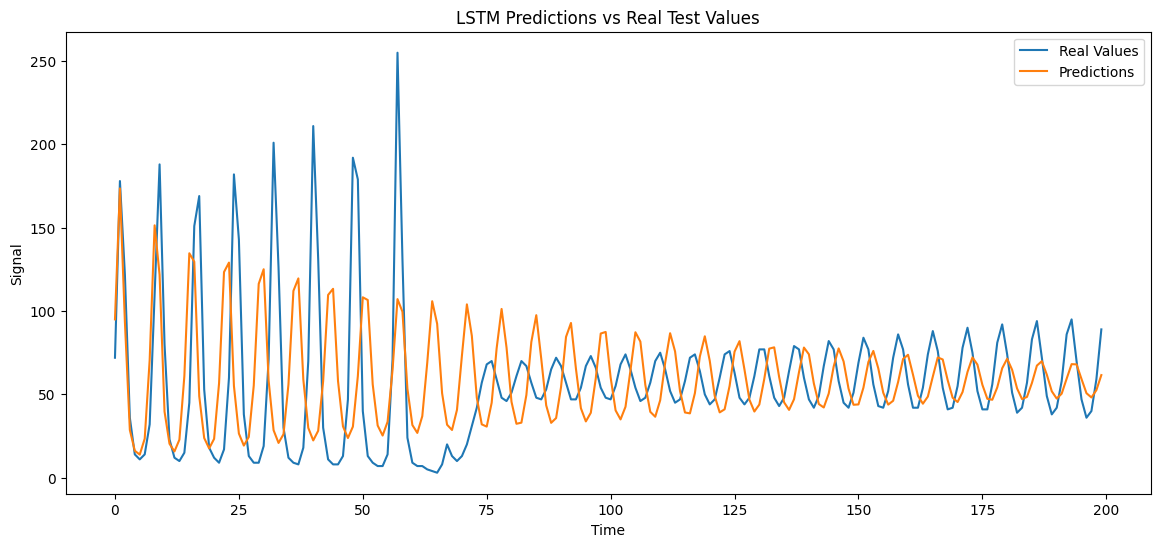

In [199]:
plt.figure(figsize=(14, 6))

plt.plot(
    true_future_inverse,
    label="Real Values"
)

plt.plot(
    predictions_inverse,
    label="Predictions"
)

plt.title("LSTM Predictions vs Real Test Values")

plt.xlabel("Time")
plt.ylabel("Signal")

plt.legend()

plt.show()

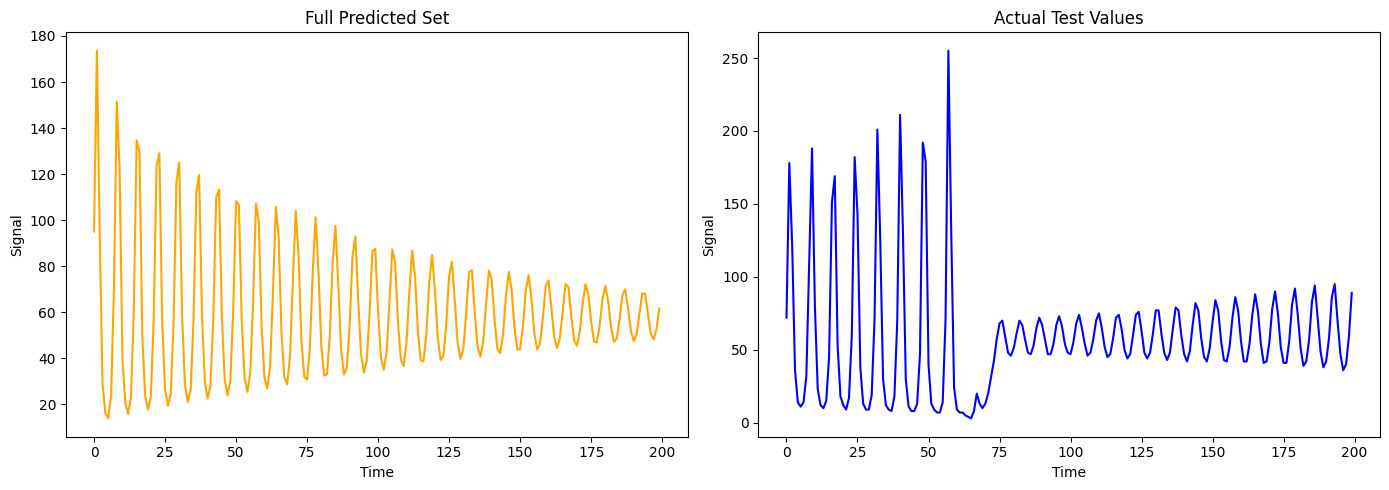

In [200]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(predictions_inverse.flatten(), color="orange")
plt.title("Full Predicted Set")
plt.xlabel("Time")
plt.ylabel("Signal")

plt.subplot(1, 2, 2)
plt.plot(true_future_inverse.flatten(), color="blue")
plt.title("Actual Test Values")
plt.xlabel("Time")
plt.ylabel("Signal")

plt.tight_layout()
plt.show()